# ECN 310 Final Project Presentation:  How do Oil Prices affect Gasoline prices?

## Introduction/Motivation

Gasoline prices play an integral role in the lives of all Americans in many ways.  American commuters feel changes in gas prices when filling their gas tanks and the rise in travel and logistics costs associated with gasoline price increases affects everyone's cost of living.  The definitive factor in the change in gasoline prices is the change of oil prices.  Due to this our project is based around Gasoline and Oil prices as main variables of interest.  Additonal control variables are examined in our extension to multivariate regression.  Overall, our results were statistically significant, and we found strong correlations between our explanatory and dependent variables.  

## Library Import

In [14]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

## Loading Data

In [15]:
# loading data from excel file
df = pd.DataFrame(pd.read_excel("Downloads/Prices_Data.xlsx", skiprows=1))
df.columns = ['Date','WTI_Oil_Price','Gulf_Coast_Gasoline_Price']
df.dropna()
df.head()

,Date,WTI_Oil_Price,Gulf_Coast_Gasoline_Price
0,2020-01-03,63.00,1.729
1,2020-01-06,63.27,1.716
2,2020-01-07,62.70,1.698
3,2020-01-08,59.65,1.628
4,2020-01-09,59.56,1.628


## Univariate Regression (OLS)

In [16]:
results=smf.ols('Gulf_Coast_Gasoline_Price ~ WTI_Oil_Price', data= df).fit()
print(results.summary())

                                OLS Regression Results                               
Dep. Variable:     Gulf_Coast_Gasoline_Price   R-squared:                       0.772
Model:                                   OLS   Adj. R-squared:                  0.772
Method:                        Least Squares   F-statistic:                     5138.
Date:                       Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                               20:37:28   Log-Likelihood:                -347.24
No. Observations:                       1516   AIC:                             698.5
Df Residuals:                           1514   BIC:                             709.1
Df Model:                                  1                                         
Covariance Type:                   nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

### Interpretation and Graph

A one dollar increase in WTI Oil price is correlated to a ~ 3 cent increase in gas prices, which is reasonable.  Additionally, the very small p value of ~ 0 supports that this is a statistically significant result.  Finally, the relatively high R squared means that approximately 77% of variance in gas price is explained by oil price, again supporting our results.  

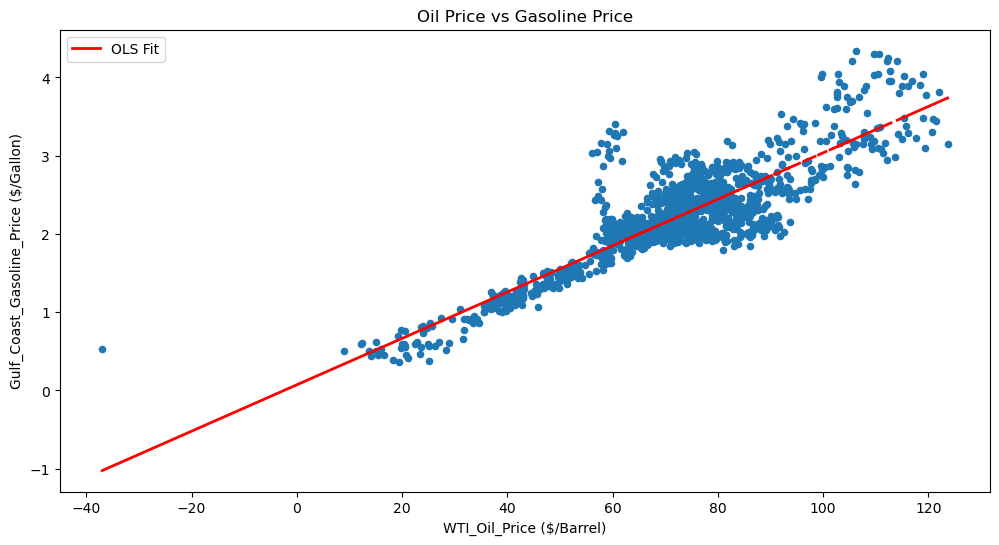

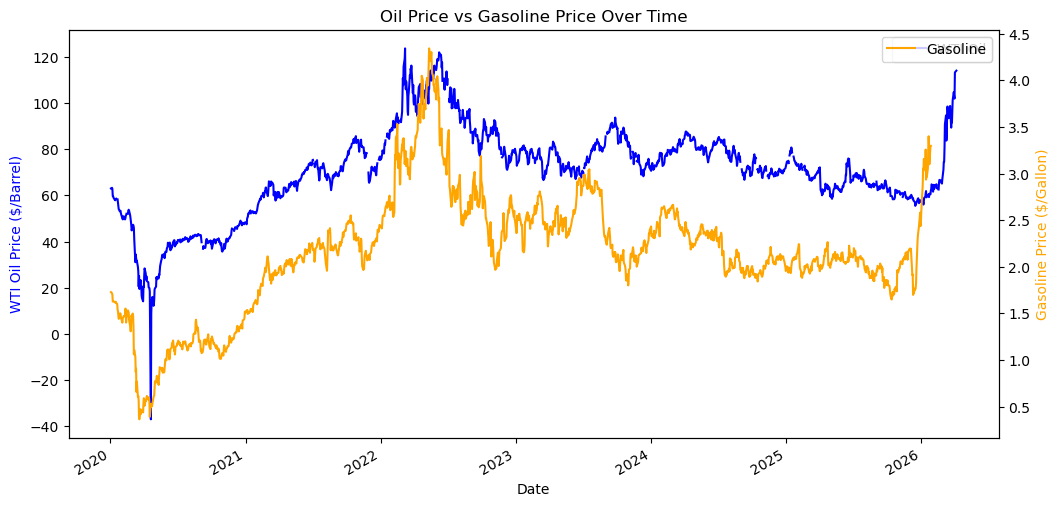

In [17]:
# Scatter Plot
fig1, ax1 = plt.subplots(figsize=(12, 6))
scatter = df.plot.scatter(x='WTI_Oil_Price', y='Gulf_Coast_Gasoline_Price', ax=ax1)
ax1.set_title('Oil Price vs Gasoline Price')
ax1.set_xlabel('WTI_Oil_Price ($/Barrel)')
ax1.set_ylabel('Gulf_Coast_Gasoline_Price ($/Gallon)')
fig1.savefig('scatter.png')
##### For the line of fit #####
df['fitted'] = results.fittedvalues
df_sorted = df.sort_values('WTI_Oil_Price')
ax1.plot(df_sorted['WTI_Oil_Price'], df_sorted['fitted'], color='red', linewidth=2, label='OLS Fit')
ax1.legend()

# Line Graph
fig2, ax2 = plt.subplots(figsize=(12, 6))
ax3 = ax2.twinx()  
df.plot(x='Date', y='WTI_Oil_Price', ax=ax2, color='blue', label='WTI Oil')
df.plot(x='Date', y='Gulf_Coast_Gasoline_Price', ax=ax3, color='orange', label='Gasoline')
ax2.set_ylabel('WTI Oil Price ($/Barrel)', color='blue')
ax3.set_ylabel('Gasoline Price ($/Gallon)', color='orange')
ax2.set_title('Oil Price vs Gasoline Price Over Time')
fig2.savefig('timeline.png')
# Note:  Due to the differing units of Oil price and Gasoline, two y axes were used for the line graph

In [18]:
# Note: the extreme outlier where oil prices are negative come from April of 2020 where crude oil futures briefly traded at a negative price

## Multivariate Regression

We extended our initial analysis into a multivariate regression to capture and control for more variables.  This increased the significance and reliability of our results.  

### Loading New Data

In [19]:
dfc= pd.read_excel('new_data.xlsx')
## Cleaning Data ##
dfd = dfc.drop(columns=['Distribution_and_Marketing_Price'])
dfm = dfd.dropna()
dfm.head()

,Date,WTI_Oil_Price,Gulf_Coast_Gasoline_Price,Taxes,Refining_Price
0,2020-01-03,63.00,1.729,0.481572,0.22932
3,2020-01-06,63.27,1.716,0.481572,0.22932
4,2020-01-07,62.70,1.698,0.481572,0.22932
5,2020-01-08,59.65,1.628,0.481572,0.22932
6,2020-01-09,59.56,1.628,0.481572,0.22932


## Running Multivariate Regression

In [20]:
resultsm = smf.ols('Gulf_Coast_Gasoline_Price ~ WTI_Oil_Price+Taxes+Refining_Price', data=dfm).fit()
print(resultsm.summary())

                                OLS Regression Results                               
Dep. Variable:     Gulf_Coast_Gasoline_Price   R-squared:                       0.823
Model:                                   OLS   Adj. R-squared:                  0.823
Method:                        Least Squares   F-statistic:                     2343.
Date:                       Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                               20:37:29   Log-Likelihood:                -156.88
No. Observations:                       1516   AIC:                             321.8
Df Residuals:                           1512   BIC:                             343.1
Df Model:                                  3                                         
Covariance Type:                   nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

### Interpretation

##### WTI_Oil_Price:  A 1 dollar increase in prices of oil per barrel reslts in a ~ 2 cent increase in gasoline price per gallon.
##### Taxes:  A 1 Dollar increase in tax per barrel of oil results in a ~3.35 dollar increase in price of gasoline per gallon.  
##### Refining_Price:  A 1 dollar increase in the price to refine a barrel of oil results in an ~ 83 cent increase in the price of gasoline per gallon. 

The extremely small P values and the confidence intervals support that this is a statistically significant observation.  Additionally, the R squared value suggests that 82.3% of variance in gasoline prices are explained by oil price, taxes or refining prices.  The fact that this is higher now than in the univariate regression suggests that the new variables added have increased reliability of results.  

## Conclusion and Limitations

Both the univariate and multivariate regression showed promising results.  We  found a statstically significant relationship between oil and gas prices.  We additionally found a relationship between oil, tax and refining prices with gas prices in a multivariate regression. If our null hypothesis was "gasoline and oil prices were not correlated positively" we would reject it.  All of these results make sense intuitively, that rising prices in gasoline inputs would increase gasoline prices. 

Our analysis could have some limitations though.  One likely limitation could be ommited variable bias.  We decided not to analyze the affect that distribution and marketing prices would have on gasoline, for example.  If we had done this, we may have been able to produce stronger and more reliable results.  Another issue in our causal analysis could be the chosen timeframe.  Covid-19 price shocks heavily affected our data, for example the negative oil prices seen in April of 2020.

Nonetheless, the statistical tools and causal methods make us reaonably confident in the reliability and significance of our results.  